# LAB 4: CATEGORICAL AND NUMERIC VARIABLES
# NAME: ENYA TRAN

Q1.
1. Set up a grid of K equally spaced values between 0 and 1, {1/K, 2/K, ..., K/K}.
2. Draw a point from the grid at random with equal probability.
3. For a very small K, repeat the above process n = 5_000 times, and plot the ECDF of the draws.
4. What distribution does this approach as you increase K?

In [1]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy.stats import ecdf, uniform

In [14]:
# Choose parameter K = 5 and repeat n = 5000 times
rng = np.random.default_rng(100)
K = 5
n = 5000

In [15]:
# 1. Set up the grid
grid = np.arange(1, K+1)/K

In [16]:
# 2. Draw a point from the grid at random with equal probability.
random = rng.choice(grid, size=n, replace=True)

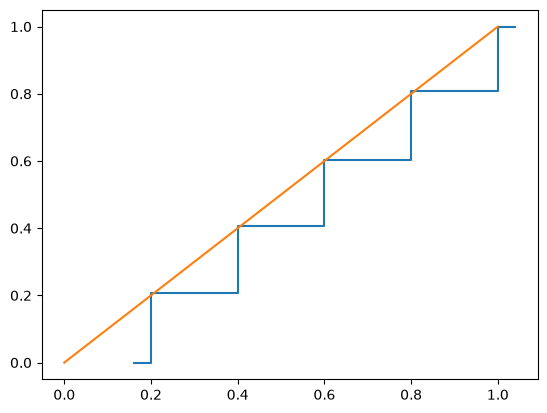

In [17]:
# 3. For a very small K, repeat the above process n = 5_000 times, and plot the ECDF of the draws.
result = ecdf(random)
result.cdf.plot()
x = np.linspace(0,1,1000)
plt.plot(
    x,
    uniform.cdf(x,loc=0,scale=1))

4. As K increases, it will approach a continuous uniform (0,1) distribution because the gap will become tinier and make each part of the interval equally likely. 

Q2.
1. Draw n = 32 values from Uniform[-sqrt(3), sqrt(3)]; these are your data. The choice of ±3 ensures each draw has mean 0 and variance 1.
2. For this sample, compute the mean and multiply by np.sqrt(n).
3. Repeat the above process b = 5_000 times and plot the ECDF.
4. What distribution does this approach as n increases?

In [27]:
from scipy.stats import norm

In [26]:
# Choose parameters n = 32 and b = 5000
n = 32
b= 5000

In [31]:
# 1. Draw n = 32 values from Uniform[-sqrt(3), sqrt(3)]; these are your data
sample = rng.uniform(
    low=-np.sqrt(3),
    high=np.sqrt(3),
    size=(b,n)
)

In [ ]:
# 2. For this sample, compute the mean and multiply by np.sqrt(n)
sample_mean = sample.mean(axis=1) #calculate 5000 sample means for each row

In [35]:
standardized_mean = sample_mean * np.sqrt(n)

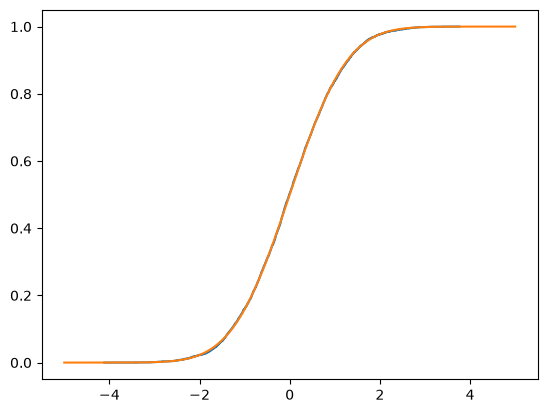

In [39]:
# 3. Repeat the above process b = 5_000 times and plot the ECDF.
result = ecdf(standardized_mean)
result.cdf.plot()
x = np.linspace(-5,5,1000)
plt.plot(
    x,
    norm.cdf(x,loc=0,scale=1)
)

4. As n increases, it approaches a normal distribution. Based on the Central Limit Theorem, as n gets larger, the average of randome variables will become normally distrbuted.

Q3.

1. Flip n = 40 coins, which each come up heads with probability p = 1/2 and tails with complementary probability.
2. From the final count of heads, subtract the expected number of heads, n * p.
3. Divide by the standard deviation sqrt( n * p * (1-p) ).
4. Repeat the above process b = 5_000 times and plot the ECDF.
5. What distribution does this approach as n increases?
6. How do the results change as you adjust p?

In [40]:
# Choose parameters n = 40, b = 5000, p = 1/2
n = 40
p = 0.5
b = 5000

In [41]:
# 1. Flip n = 40 coins, which each come up heads with probability p = 1/2 and tails with complementary probability
head_counts = rng.binomial(n=n, p=p, size=b)

In [42]:
# 2. From the final count of heads, subtract the expected number of heads, n * p.
expected_counts = head_counts - n*p

In [44]:
# 3. Divide by the standard deviation sqrt( n * p * (1-p) ).
standardized_counts = expected_counts / np.sqrt(n*p*(1-p))

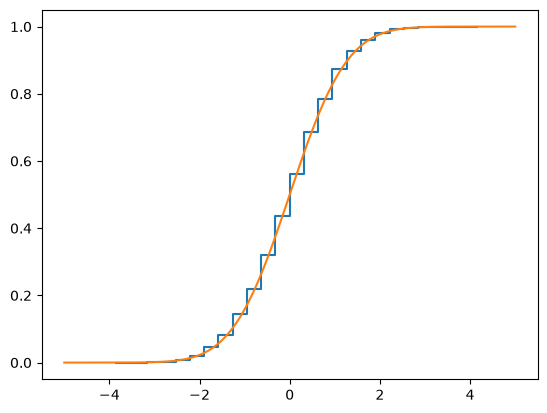

In [45]:
# 4. Repeat the above process b = 5_000 times and plot the ECDF.
result = ecdf(standardized_counts)
result.cdf.plot()
plt.plot(
    x,
    norm.cdf(x,loc=0,scale=1)
)

5. As n increases, it will approach a normal distribution because the number of heads become more bell-shaped

6. When p is 0.5, the distribution will be symmetric and more normal looking. When p is closer to 0, most experiments will produce only a few heads, so the distribution is right-skewed. When p is closer to 1, most experiments have many heads, so the distribution is left-skewed.

Q4.

1. For each simulation of the process, determine the period in which termination occurs.
2. Convert periods to time by multiplying by dt.
3. Repeat the simulation n = 5_000 times and plot the ECDF, for a value of dt close to zero (e.g. dt = 1e-3).
4. What distribution does this approach as dt goes to zero?
5. How do the results change as you adjust r?

In [46]:
from scipy.stats import expon 

dt = 1e-3
r = 1
n = 5000

In [58]:
#1. For each simulation of the process, determine the period in which termination occurs.
termination_period = np.empty(n)

for x in range(n):
    period = 0
    while True:
        period = period + 1
        if rng.random() < r*dt:
            break
    termination_period[x] = period

termination_period

array([1584.,  244., 1073., ..., 2042.,  112., 3681.], shape=(5000,))

In [61]:
# 2. Convert periods to time by multiplying by dt.
termination_time = termination_period * dt
termination_time

array([1.584, 0.244, 1.073, ..., 2.042, 0.112, 3.681], shape=(5000,))

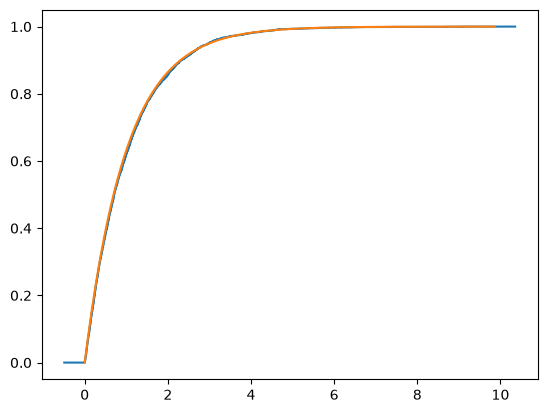

In [62]:
# 3. Repeat the simulation n = 5_000 times and plot the ECDF, for a value of dt close to zero (e.g. dt = 1e-3).
result = ecdf(termination_time)
result.cdf.plot()
x = np.linspace(0, termination_time.max(), 1_000)

plt.plot(
    x,
    expon.cdf(x, scale=1 / r),
)

4. As dt gets closer to 0, the termination times approach an exponential distribution because the process has equal chance of terminating during each small time interval

5. When r increases, the chance of termination will increase for each period, so the process will terminate sooner. When r decreases, the process will last longer. 